In [45]:
import os
import sys
import torch
import os.path
import argparse
import urllib.request

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from data import *
from utils import *
from ExtraLoss import *

from PIL import Image
from datetime import datetime
from sklearn.mixture import GaussianMixture as GMM
from sklearn.model_selection import train_test_split

sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Disentanglement'))
sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Accuracy'))

from DCI import compute_dci, report_dci
from IRS import compute_irs_from_multihot_labels
from MIG import compute_mig

from BA import mh_binary_accuracy

In [46]:
parser = argparse.ArgumentParser(description='Gen-RKM Model')

parser.add_argument('--N', type=int, default=1000, help='Total # of samples') # 1000
parser.add_argument('--mb_size', type=int, default=100, help='Mini-batch size. See utils.py')
parser.add_argument('--h_dim', type=int, default=40, help='Dim of latent vector')
parser.add_argument('--capacity', type=int, default=32, help='Capacity of network. See utils.py')
parser.add_argument('--x_fdim', type=int, default=128, help='Input x_fdim. See utils.py')
parser.add_argument('--y_fdim', type=int, default=20, help='Input y_fdim. See utils.py')
parser.add_argument('--c_accu', type=float, default=100, help='Input weight on recons_error')
parser.add_argument('--start_iter', type=int, default=0, help='Input start_iter for training')

parser.add_argument('--lr', type=float, default=1e-4, help='Input learning rate for optimizer')
parser.add_argument('--max_epochs', type=int, default=0, help='Input max_epoch for cut-off') # 5000
parser.add_argument('--device', type=str, default='cpu', help='Device type: cuda or cpu')
parser.add_argument('--workers', type=int, default=0, help='# of workers for dataloader')
parser.add_argument('--shuffle', type=bool, default=True, help='shuffle dataset: true or false')

opt, _ = parser.parse_known_args()

h_dim = opt.h_dim

In [47]:
xtrain, xtest, ipVec_dim, nChannels = get_mmcelebahq_dataloader(args=opt)

info 0 1000 1
info 1001 2001 1


In [48]:
ct = time.strftime("%Y%m%d-%H%M")
dirs = create_dirs(ct=ct)
dirs.create()

In [49]:
def kPCA(X, Y, Z, eps=1e-6):
    # Kernel matrix (B,B)
    # print('Shapes of KPCA input:', X.shape, Y.shape, Z.shape)

    a = X @ X.T + Y @ Y.T + Z @ Z.T / 3
    B = a.size(0)

    # Centering (same dtype/device as a)
    oneN = torch.ones(B, B, device=a.device, dtype=a.dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    # Force symmetry (numerical)
    a = 0.5 * (a + a.T)

    # Add small jitter to diagonal for conditioning
    a = a + eps * torch.eye(B, device=a.device, dtype=a.dtype)

    # Eigen-decomposition (ascending eigenvalues)
    evals, evecs = torch.linalg.eigh(a)

    # Sort descending
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    # Return top components
    h = evecs[:, :h_dim]
    s = evals  # (B,)

    return h, s

In [50]:
def partial_kPCA(views, eps=1e-6, etas=None, normalize_missing=False):
    if len(views) == 0:
        raise ValueError("At least one view is required.")

    device = views[0].device
    dtype = views[0].dtype
    B = views[0].size(0)

    for v in views:
        if v.size(0) != B:
            raise ValueError("All views must have the same batch size.")

    if etas is None:
        etas = [1.0] * len(views)
    if len(etas) != len(views):
        raise ValueError("len(etas) must match len(views).")

    # Sum weighted Gram matrices
    a = torch.zeros(B, B, device=device, dtype=dtype)
    for v, eta in zip(views, etas):
        a = a + (v @ v.T) / eta

    # Optional: compensate for missing views by keeping scale comparable
    if normalize_missing:
        a = a / len(views)

    # Center
    oneN = torch.ones(B, B, device=device, dtype=dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    # Symmetrize + jitter
    a = 0.5 * (a + a.T)
    a = a + eps * torch.eye(B, device=device, dtype=dtype)

    # Eigendecomposition
    evals, evecs = torch.linalg.eigh(a)
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    h = evecs[:, :h_dim]
    s = evals[:h_dim]

    return h, s

In [51]:
# Energy function
def my_loss(output_im, data_im, output_sk, data_sk, output_la, data_la):
    h, s = kPCA(output_im, output_sk, output_la) # Latent representation and eigenvalues

    U = torch.mm(torch.t(output_im), h) # Get encoded data back from the latent representation
    V = torch.mm(torch.t(output_sk), h)
    W = torch.mm(torch.t(output_la), h)

    x_im_tilde = net_im_de(torch.mm(h, torch.t(U))) # Reconstruction of the input
    x_sk_tilde = net_sk_de(torch.mm(h, torch.t(V)))
    x_la_tilde = net_la_de(torch.mm(h, torch.t(W)))

    # cost
    f1 = torch.trace(torch.mm(torch.mm(output_im, U), torch.t(h))) + torch.trace(torch.mm(torch.mm(output_sk, V), torch.t(h))) + torch.trace(torch.mm(torch.mm(output_la, W), torch.t(h)))
    f2 = 0.5 * torch.trace(torch.mm(h, torch.mm(torch.diag(s[:h_dim]), torch.t(h))))
    f3 = 0.5 * ((torch.trace(torch.mm(torch.t(U), U))) + (torch.trace(torch.mm(torch.t(V), V))) + (torch.trace(torch.mm(torch.t(W), W))))

    recon_loss1 = torch.nn.MSELoss()
    recon_loss2 = torch.nn.MSELoss()
    recon_loss3 = torch.nn.BCEWithLogitsLoss()
    f4 = recon_loss1(x_im_tilde.view(-1, 49152), data_im.view(-1, 49152)) + recon_loss2(x_sk_tilde.view(-1, 16384), data_sk.view(-1, 16384)) + recon_loss3(x_la_tilde.view(-1, 40), data_la.view(-1, 40))  # reconstruction loss

    loss = - f1 + f3 + f2 + 0.5 * (- f1 + f3 + f2) ** 2 + 100 * f4
    return loss

In [52]:
net_im_en = NetImEn().double().to(opt.device)
net_sk_en = NetSkEn().double().to(opt.device)
net_la_en = NetLaEn().double().to(opt.device)

net_im_de = NetImDe().double().to(opt.device)
net_sk_de = NetSkDe().double().to(opt.device)
net_la_de = NetLaDe().double().to(opt.device)

In [53]:
params = list(net_im_en.parameters()) + list(net_sk_en.parameters()) + list(net_la_en.parameters()) + list(net_im_de.parameters()) + list(net_sk_de.parameters()) + list(net_la_de.parameters())
optimizer = torch.optim.Adam(params, lr=learning_rate, weight_decay=0)

l_cost = 6  # Costs from where checkpoints will be saved
t = 1
cost = np.inf  # Initialize cost

losses = []

In [54]:
while cost > 0.2 and t <= opt.max_epochs:  # run epochs until convergence
    permutation = torch.randperm(opt.N)
    avg_loss = 0
    for i, (data_im, data_sk, data_la) in enumerate(xtrain):
        data_im = data_im.to(opt.device)                                            # Get mini-batch and send to device (10 times 100 samples)
        data_sk = data_sk.to(opt.device)
        data_la = data_la.to(opt.device)
        
        output_im = net_im_en(data_im)
        output_sk = net_sk_en(data_sk)
        output_la = net_la_en(data_la)

        loss = my_loss(output_im, data_im, output_sk, data_sk, output_la, data_la)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        avg_loss += loss.detach().cpu().numpy()
        
    cost = avg_loss

    # Remember lowest cost and save checkpoint
    is_best = cost < l_cost
    l_cost = min(cost, l_cost)
    dirs.save_checkpoint({
        'epochs': t + 1,
        'net_im_en_state_dict': net_im_en.state_dict(),
        'net_sk_en_state_dict': net_sk_en.state_dict(),
        'net_la_en_state_dict': net_la_en.state_dict(),

        'net_im_de_state_dict': net_im_de.state_dict(),
        'net_sk_de_state_dict': net_sk_de.state_dict(),
        'net_la_de_state_dict': net_la_de.state_dict(),

        'l_cost': l_cost,
        'optimizer': optimizer.state_dict()}, is_best)

    print(t, cost)
    losses.append(cost)
    t += 1
print('Finished Training. Lowest cost: {}'.format(l_cost))

Finished Training. Lowest cost: 6


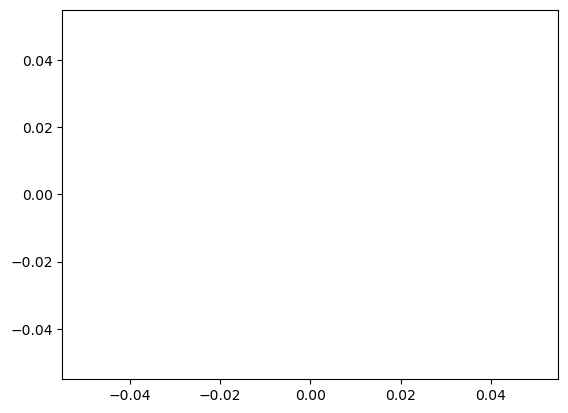

In [55]:
# Plot losses
plt.plot(losses)

In [56]:
# # Get latest model
# if os.path.exists('cp/{}'.format(dirs.dircp)):
#     sd_mdl = torch.load('cp/{}'.format(dirs.dircp), weights_only=False)
#     net_im_en.load_state_dict(sd_mdl['net_im_en_state_dict'])
#     net_sk_en.load_state_dict(sd_mdl['net_sk_en_state_dict'])
#     net_la_en.load_state_dict(sd_mdl['net_la_en_state_dict'])

#     net_im_de.load_state_dict(sd_mdl['net_im_de_state_dict'])
#     net_sk_de.load_state_dict(sd_mdl['net_sk_de_state_dict'])
#     net_la_de.load_state_dict(sd_mdl['net_la_de_state_dict'])

# U, V, W, h, s = mmcelebahq_final_compute(opt, net_im_en, net_sk_en, net_la_en, kPCA)

In [57]:
# # Save Model
# torch.save({'net_im_en': net_im_en,
#             'net_sk_en': net_sk_en,
#             'net_la_en': net_la_en,

#             'net_im_de': net_im_de,
#             'net_sk_de': net_sk_de,
#             'net_la_de': net_la_de,


#             'net_im_en_state_dict': net_im_en.state_dict(),
#             'net_sk_en_state_dict': net_sk_en.state_dict(),
#             'net_la_en_state_dict': net_la_en.state_dict(),

#             'net_im_de_state_dict': net_im_de.state_dict(),
#             'net_sk_de_state_dict': net_sk_de.state_dict(),
#             'net_la_de_state_dict': net_la_de.state_dict(),

#             'data_im': data_im,
#             'data_sk': data_sk,
#             'data_la': data_la,
#             'classes': get_classes(),
#             'h': h, 'N': N, 's': s, 'U': U, 'V': V, 'W': W}, 'out/{}'.format(dirs.dirout))

In [58]:
model = torch.load('./out/5000_1000.tar', weights_only=False)

U = model['U']
V = model['V']
W = model['W']
h = model['h']
s = model['s']

data_im = model['data_im']
data_sk = model['data_sk']
data_la = model['data_la']

net_im_en = model['net_im_en']
net_sk_en = model['net_sk_en']
net_la_en = model['net_la_en']

net_im_de = model['net_im_de']
net_sk_de = model['net_sk_de']
net_la_de = model['net_la_de']

In [59]:
h.shape

torch.Size([1000, 40])

## Evaluation

In [60]:
recon_loss = torch.nn.MSELoss(reduction="mean")

net_im_en.eval()
net_sk_en.eval()
net_la_en.eval()
net_im_de.eval()
net_sk_de.eval()
net_la_de.eval()

im_loss_sum = 0.0
sk_loss_sum = 0.0
la_loss_sum = 0.0
loss_sum = 0.0
n = 0

in_data_im_test = []
in_data_sk_test = []
in_data_la_test = []

out_data_im_test = []
out_data_sk_test = []
out_data_la_test = []

with torch.no_grad():
    for data_im, data_sk, data_la in xtest:
        data_im = data_im.to(opt.device)                    # Get the data from the dataloader
        data_sk = data_sk.to(opt.device)
        data_la = data_la.to(opt.device)

        in_data_im_test.append(data_im.cpu().numpy())       # Store the input data for later visualization
        in_data_sk_test.append(data_sk.cpu().numpy())
        in_data_la_test.append(data_la.cpu().numpy())

        data_im_en = net_im_en(data_im)                     # Encode the data using the trained encoder networks
        data_sk_en = net_sk_en(data_sk)
        data_la_en = net_la_en(data_la)

        _h, s = kPCA(data_im_en, data_sk_en, data_la_en)     # Get the latent representation and eigenvalues using kPCA
        # _h, s = partial_kPCA([data_im_en, data_sk_en])       # Get the latent representation and eigenvalues using partial kPCA

        U = torch.mm(torch.t(data_im_en), _h)                # Get encoded data back from the latent representation
        V = torch.mm(torch.t(data_sk_en), _h)
        W = torch.mm(torch.t(data_la_en), _h)

        x_im_tilde = net_im_de(torch.mm(_h, torch.t(U)))     # Reconstruction of the input
        x_sk_tilde = net_sk_de(torch.mm(_h, torch.t(V)))
        x_la_tilde = net_la_de(torch.mm(_h, torch.t(W)))

        out_data_im_test.append(x_im_tilde.cpu().numpy())   # Save data for later visualization
        out_data_sk_test.append(x_sk_tilde.cpu().numpy())
        out_data_la_test.append(x_la_tilde.cpu().numpy())

        B = data_im.size(0)                                 # Get the batch size for loss calculation

        im_loss = recon_loss(x_im_tilde.view(B, -1), data_im.view(B, -1))
        sk_loss = recon_loss(x_sk_tilde.view(B, -1), data_sk.view(B, -1))
        la_loss = 1 - mh_binary_accuracy(data_la.cpu().numpy(), x_la_tilde.view(B, -1).cpu().numpy())

        im_loss_sum += im_loss.item() * B
        sk_loss_sum += sk_loss.item() * B
        la_loss_sum += la_loss.item() * B

        loss_sum += (im_loss + sk_loss + la_loss).item() / 3 * B
        n += B

test_im_loss = im_loss_sum / n
test_sk_loss = sk_loss_sum / n
test_la_loss = la_loss_sum / n
test_loss = loss_sum / n

print("Total Test Reconstruction Loss:", test_loss)
print("Image Loss: :", test_im_loss)
print("Sketch Loss:", test_sk_loss)
print("Label Loss:", test_la_loss)

Total Test Reconstruction Loss: 0.08851278130515967
Image Loss: : 0.0333071362520161
Sketch Loss: 0.0983562076634629
Label Loss: 0.133875


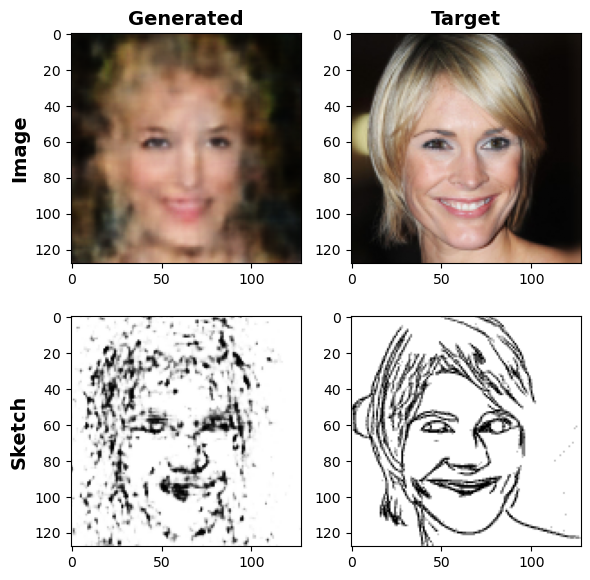

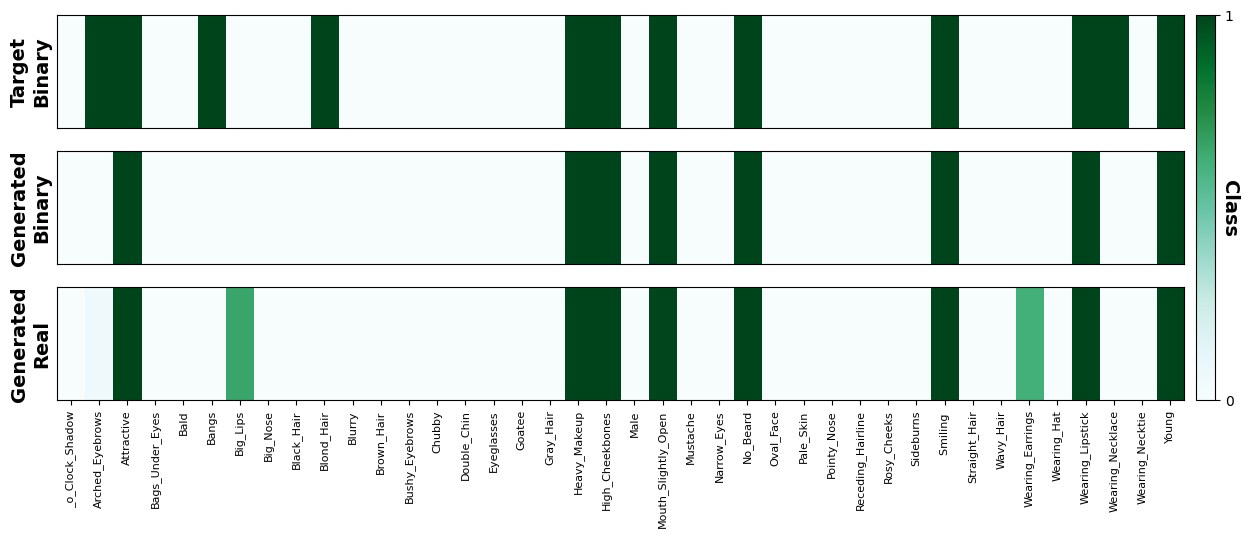

In [61]:
target_index = 0

in_image = in_data_im_test[0][target_index].transpose(1, 2, 0)
in_sketch = in_data_sk_test[0][target_index].transpose(1, 2, 0)
in_label = in_data_la_test[0][target_index]

out_image = out_data_im_test[0][target_index].transpose(1, 2, 0)
out_sketch = out_data_sk_test[0][target_index].transpose(1, 2, 0)
out_label = out_data_la_test[0][target_index]

# Plot Image + Sketch
fig, ax = plt.subplots(2, 2, figsize=(6, 6))

ax[0,0].imshow(out_image)
ax[0,0].set_title('Generated', size=14, weight='bold')
ax[0,0].set_ylabel('Image', rotation=90, size=14, weight='bold')

ax[1,0].imshow(out_sketch, cmap='gray')
ax[1,0].set_ylabel('Sketch', rotation=90, size=14, weight='bold')

ax[0,1].imshow(in_image)
ax[0,1].set_title('Target', size=14, weight='bold')

ax[1,1].imshow(in_sketch, cmap='gray')

plt.tight_layout()
plt.show()

# Plot Labels
fig, ax = plt.subplots(3, 1, figsize=(15, 5))
ax[0].imshow(in_label.reshape(1, -1), cmap='BuGn', aspect='auto')
ax[0].set_yticks([])
ax[0].set_xticks([])
ax[0].set_ylabel('Target\nBinary', rotation=90, size=14, weight='bold')

ax[1].imshow((out_label.reshape(1, -1) > 0.5).astype(np.int64), cmap='BuGn', aspect='auto')
ax[1].set_yticks([])
ax[1].set_xticks([])
ax[1].set_ylabel('Generated\nBinary', rotation=90, size=14, weight='bold')

ax[2].imshow(out_label.reshape(1, -1), cmap='BuGn', aspect='auto')
ax[2].set_yticks([])
ax[2].set_xticks(range(len(get_classes())))
ax[2].set_xticklabels(get_classes(), rotation=90, size=8)
ax[2].set_ylabel('Generated\nReal', rotation=90, size=14, weight='bold')

cbar = fig.colorbar(plt.cm.ScalarMappable(cmap='BuGn'), ax=ax, orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['0', '1'])
cbar.set_label('Class', rotation=270, size=14, weight='bold')

## Disentanglement

In [62]:
# Variables with correlation < 0.3, see data_analysis.ipynb
Z_subset = ['Brown_Hair','Pointy_Nose','Bangs','Blurry','Straight_Hair','Wavy_Hair','Oval_Face','Blond_Hair','Arched_Eyebrows','Wearing_Hat','Sideburns','Wearing_Earrings','Bald']

class_names = get_classes()
subset_indices = [class_names.index(cls) for cls in Z_subset]

In [63]:
Z_s = []
Zs_s = []

with torch.no_grad():
    for data_im, data_sk, data_la in xtrain:
        data_la = data_la.to(opt.device)

        z_subset = data_la[:, subset_indices]

        Zs_s.append(z_subset.cpu().numpy())
        Z_s.append(data_la.cpu().numpy())

C = h.detach().cpu().numpy()            # use h only once
Zs = np.concatenate(Zs_s, axis=0)       # (N, 13)
Z  = np.concatenate(Z_s, axis=0)        # (N, 40)

factor_types_subset = ["discrete"] * Zs.shape[1]
factor_types_full   = ["discrete"] * Z.shape[1]

In [64]:
C.shape, Zs.shape, Z.shape

((1000, 40), (1000, 13), (1000, 40))

### DCI
> **$D$**: Latent encoding -> Factor <br>
> **$C$**: Factor -> Latent encoding <br>
> **$I$**: How well the factors can be predicted at all (predictive performance). <br>

In [65]:
res = compute_dci(C, Zs, factor_types_subset, probe="lasso")
report_dci(res, title='DCI Scores (Subset of 13 Factors)')

--- DCI Scores (Subset of 13 Factors) ---
 > Disentanglement: 0.1495
 > Completeness: 0.1135
 > Informativeness: 0.7865


### IRS

In [66]:
irs_res = compute_irs_from_multihot_labels(C, Z)

In [67]:
print(f'--- IRS Scores ---')
print(f' > Disentanglement: {round(irs_res["IRS"], 4)}')

--- IRS Scores ---
 > Disentanglement: 0.4176


### MIG

In [68]:
mig_res = compute_mig(C, Zs)

print(f'--- MIG Scores ---')
print(f' > MIG: {mig_res["MIG"]}')

--- MIG Scores ---
 > MIG: 0.007461854693281212


Text(0.5, 58.7222222222222, 'Factors')

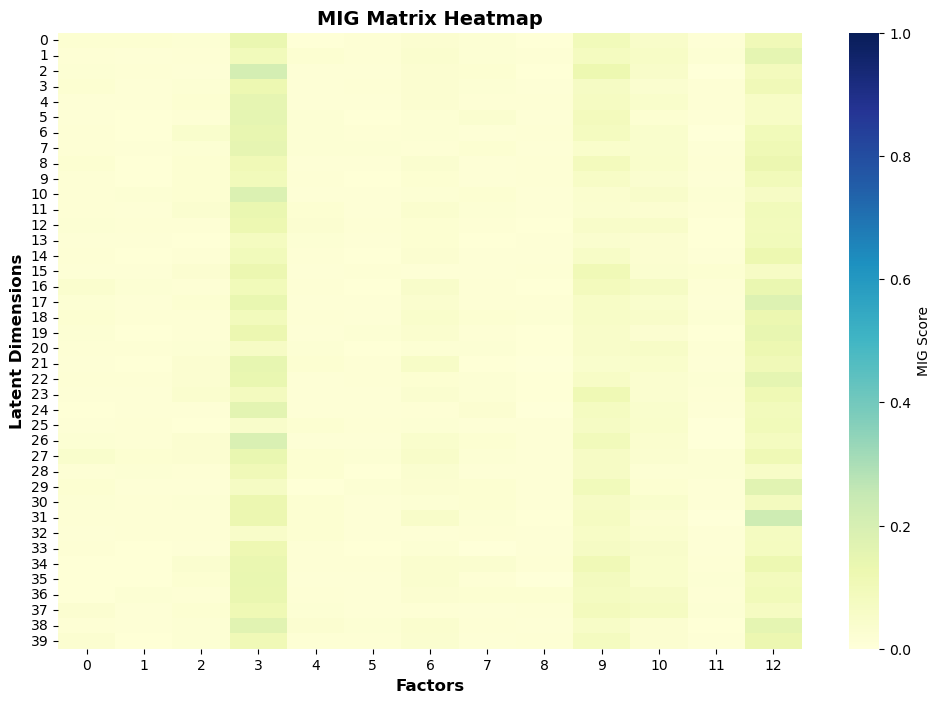

In [69]:
# Make heatmap of MIG matrix
plt.figure(figsize=(12, 8))
sns.heatmap(mig_res["MIG_matrix"], annot=False, fmt=".4f", cmap="YlGnBu", cbar_kws={'label': 'MIG Score'}, vmin=0, vmax=1)
plt.title('MIG Matrix Heatmap', size=14, weight='bold')
plt.ylabel('Latent Dimensions', size=12, weight='bold')
plt.xlabel('Factors', size=12, weight='bold')

In [70]:
mig_res["per_factor"]

array([0.00717531, 0.0001947 , 0.00294809, 0.01619993, 0.00304623,
       0.00103653, 0.00256519, 0.00040614, 0.00238744, 0.010358  ,
       0.00109637, 0.00055689, 0.04903331])

## Latent Visualization

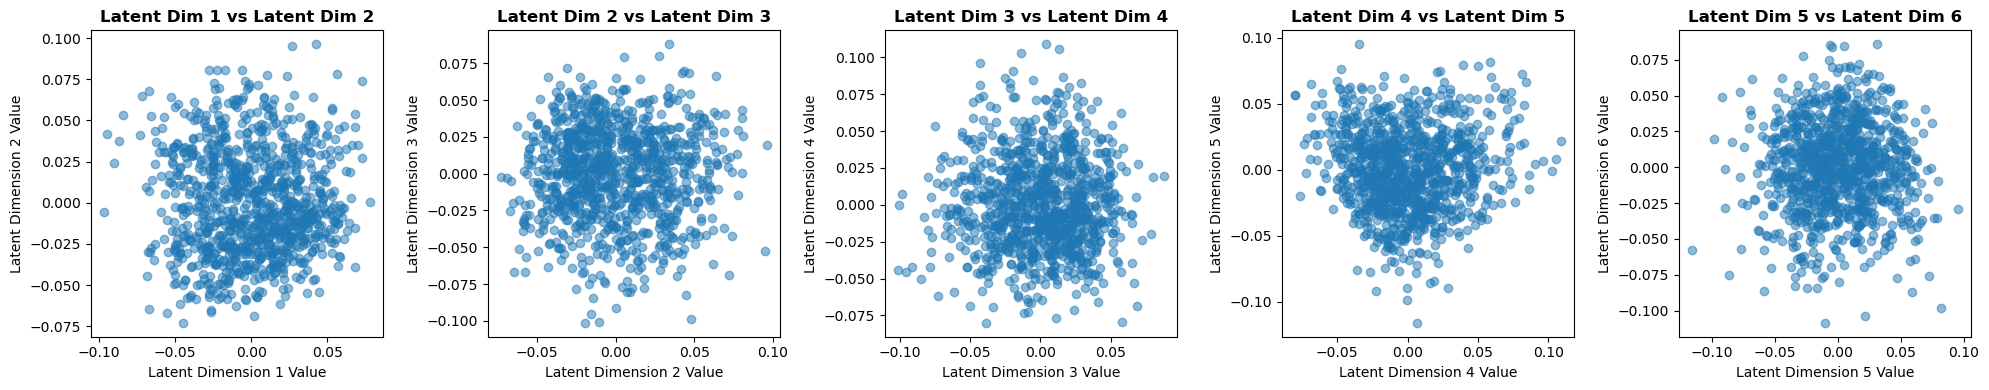

In [72]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    axes[i].scatter(h[:, i].detach().cpu(), h[:, i+1].detach().cpu(), alpha=0.5)  # Scatter plot of latent dimension vs first factor
    axes[i].set_title(f'Latent Dim {i+1} vs Latent Dim {i+2}', size=12, weight='bold')
    axes[i].set_xlabel(f'Latent Dimension {i+1} Value', size=10)
    axes[i].set_ylabel(f'Latent Dimension {i+2} Value', size=10)
plt.tight_layout()
plt.show()

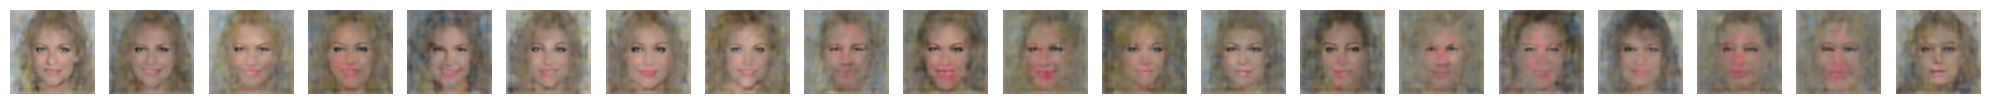

In [74]:
# Plot 20 images while walking along latent dimension 1
fig, axes = plt.subplots(1, 20, figsize=(20, 12))

for i in range(20):
    z_walk = h.clone()
    z_walk[:, 0] = torch.linspace(h[:, 0].min(), h[:, 0].max(), steps=1000)      # Walk along latent dimension 1
    x_walk_im = net_im_de(torch.mm(z_walk, torch.t(U)))                         # Decode the walked latent representation
    img = x_walk_im[i*50].detach().cpu().numpy().transpose(1, 2, 0)              # Get the i*5-th image and convert to numpy
    axes[i].imshow(img)
    axes[i].axis('off')
    
plt.tight_layout()
plt.show()